# Linear Independence: Theory, Geometry & Computation

## What is Linear Independence?

A set of vectors $\{v_1, v_2, ..., v_n\}$ is **linearly independent** if the only solution to:

$$c_1 v_1 + c_2 v_2 + ... + c_n v_n = 0$$

is the trivial solution $c_1 = c_2 = ... = c_n = 0$.

If a non-trivial solution exists (at least one $c_i \neq 0$), the vectors are **linearly dependent**.

### Geometric Meaning
- In $\mathbb{R}^2$: Two vectors are independent if they point in different directions (not collinear).
- In $\mathbb{R}^3$: Three vectors are independent if they do not all lie in the same plane.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Geometric Intuition in 2D

Two vectors in $\mathbb{R}^2$ are:
- **Independent**: They span the entire plane. Any point in $\mathbb{R}^2$ can be reached via linear combinations.
- **Dependent**: They lie on the same line. Their span is only a 1D subspace.

The left plot shows independent vectors filling the plane. The right plot shows dependent vectors (one is a scalar multiple of the other) confined to a line.


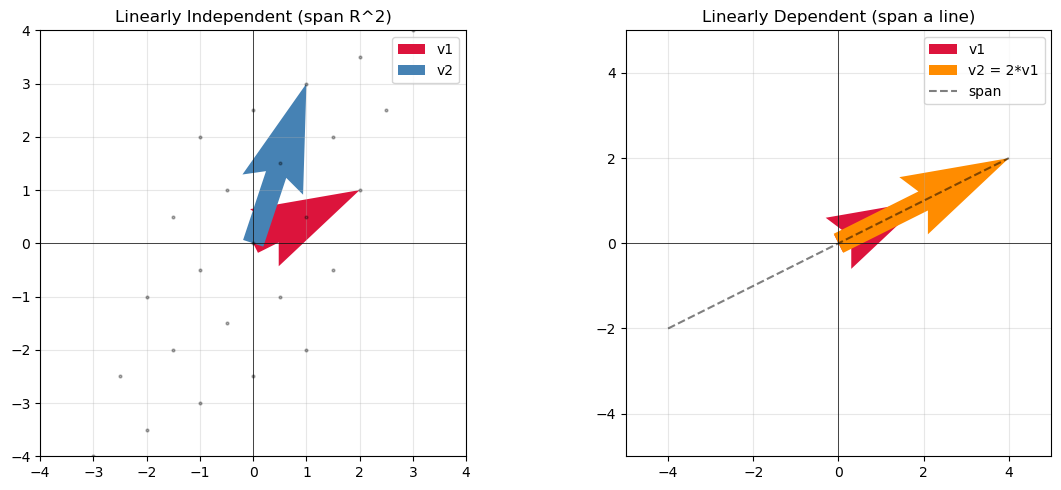

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Independent vectors ---
ax = axes[0]
v1 = np.array([2, 1])
v2 = np.array([1, 3])
origin = np.array([0, 0])

ax.quiver(*origin, *v1, color='crimson', angles='xy', scale_units='xy', scale=1, width=0.05, label='v1')
ax.quiver(*origin, *v2, color='steelblue', angles='xy', scale_units='xy', scale=1, width=0.05, label='v2')

# Span grid: all integer combos in [-1,1]
for a in np.linspace(-1, 1, 5):
    for b in np.linspace(-1, 1, 5):
        point = a * v1 + b * v2
        ax.plot(point[0], point[1], 'ko', markersize=2, alpha=0.3)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('Linearly Independent (span R^2)')
ax.legend()

# --- Dependent vectors ---
ax = axes[1]
v1 = np.array([2, 1])
v2 = np.array([4, 2])  # scalar multiple: 2*v1

ax.quiver(*origin, *v1, color='crimson', angles='xy', scale_units='xy', scale=1, width=0.05, label='v1')
ax.quiver(*origin, *v2, color='darkorange', angles='xy', scale_units='xy', scale=1, width=0.05, label='v2 = 2*v1')

# Draw span line
t = np.linspace(-2, 2, 100)
line = np.outer(t, v1)
ax.plot(line[:, 0], line[:, 1], 'k--', alpha=0.5, label='span')

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('Linearly Dependent (span a line)')
ax.legend()

plt.tight_layout()
plt.show()


## 2. Testing Independence Algebraically

### Method 1: Determinant (for square matrices)
For $n$ vectors in $\mathbb{R}^n$, form a matrix $A$ with the vectors as columns.
- $\det(A) \neq 0$ → vectors are **independent**
- $\det(A) = 0$ → vectors are **dependent**

### Method 2: Matrix Rank
- $\text{rank}(A) = n$ (full rank) → **independent**
- $\text{rank}(A) < n$ → **dependent**

### Method 3: Linear System
Solve $A c = 0$. If the only solution is $c = 0$, the columns are independent.


In [3]:
# Example 1: Independent vectors in R3
A_indep = np.array([
    [1, 2, 1],
    [0, 1, 3],
    [2, 0, 1]
], dtype=float)

print("=== Independent Set in R^3 ===")
print("Matrix A:")
print(A_indep)
print(f"Determinant: {np.linalg.det(A_indep):.6f}")
print(f"Rank: {np.linalg.matrix_rank(A_indep)}")
print(f"Shape: {A_indep.shape}")
status = 'Independent' if np.linalg.matrix_rank(A_indep) == A_indep.shape[1] else 'Dependent'
print(f"Conclusion: {status}")

print()

# Example 2: Dependent vectors in R3 (third is sum of first two)
A_dep = np.array([
    [1, 2, 3],
    [0, 1, 1],
    [2, 0, 2]
], dtype=float)

print("=== Dependent Set in R^3 ===")
print("Matrix A:")
print(A_dep)
print(f"Determinant: {np.linalg.det(A_dep):.6f}")
print(f"Rank: {np.linalg.matrix_rank(A_dep)}")
print(f"Shape: {A_dep.shape}")
status = 'Independent' if np.linalg.matrix_rank(A_dep) == A_dep.shape[1] else 'Dependent'
print(f"Conclusion: {status}")

# Find the exact dependency relation
coeffs = np.linalg.lstsq(A_dep[:, :2], A_dep[:, 2], rcond=None)[0]
print(f"Dependency: v3 = {coeffs[0]:.2f}*v1 + {coeffs[1]:.2f}*v2")


=== Independent Set in R^3 ===
Matrix A:
[[1. 2. 1.]
 [0. 1. 3.]
 [2. 0. 1.]]
Determinant: 11.000000
Rank: 3
Shape: (3, 3)
Conclusion: Independent

=== Dependent Set in R^3 ===
Matrix A:
[[1. 2. 3.]
 [0. 1. 1.]
 [2. 0. 2.]]
Determinant: 0.000000
Rank: 2
Shape: (3, 3)
Conclusion: Dependent
Dependency: v3 = 1.00*v1 + 1.00*v2


## 3. Geometric Intuition in 3D

In $\mathbb{R}^3$:
- **1 vector** spans a line.
- **2 independent vectors** span a plane.
- **3 independent vectors** span the entire volume.

Three vectors are dependent if they all lie in the same plane (coplanar) or on the same line (collinear), even if no two vectors are scalar multiples of each other.

The plots below show:
1. Three independent vectors forming a parallelepiped.
2. Three dependent (coplanar) vectors lying in the XY-plane.

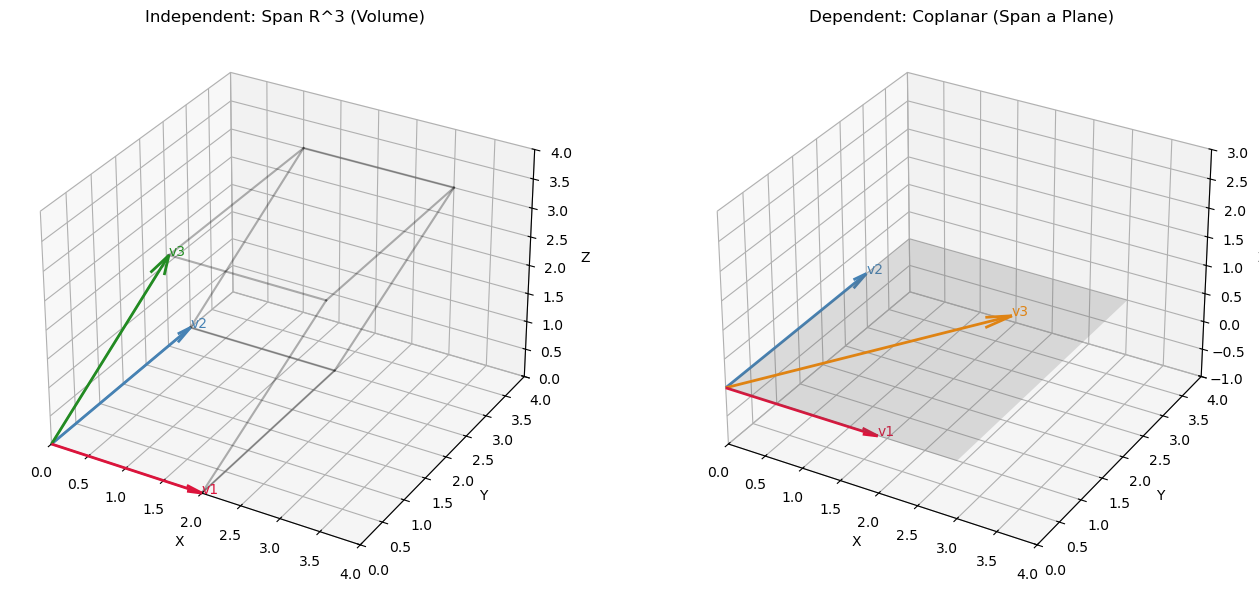

In [4]:
fig = plt.figure(figsize=(14, 6))

# --- Independent vectors in 3D ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

v1 = np.array([2, 0, 0])
v2 = np.array([0, 3, 0])
v3 = np.array([1, 1, 3])
origin = np.zeros(3)

ax1.quiver(*origin, *v1, color='crimson', arrow_length_ratio=0.1, linewidth=2)
ax1.quiver(*origin, *v2, color='steelblue', arrow_length_ratio=0.1, linewidth=2)
ax1.quiver(*origin, *v3, color='forestgreen', arrow_length_ratio=0.1, linewidth=2)

# Draw parallelepiped edges
for a in [0, 1]:
    for b in [0, 1]:
        for c in [0, 1]:
            p = a*v1 + b*v2 + c*v3
            if a == 0: ax1.plot3D(*zip(p, p+v1), 'k-', alpha=0.3)
            if b == 0: ax1.plot3D(*zip(p, p+v2), 'k-', alpha=0.3)
            if c == 0: ax1.plot3D(*zip(p, p+v3), 'k-', alpha=0.3)

ax1.set_xlim(0, 4)
ax1.set_ylim(0, 4)
ax1.set_zlim(0, 4)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Independent: Span R^3 (Volume)')
ax1.text(2, 0, 0, 'v1', color='crimson')
ax1.text(0, 3, 0, 'v2', color='steelblue')
ax1.text(1, 1, 3, 'v3', color='forestgreen')

# --- Dependent vectors in 3D (coplanar) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

v1 = np.array([2, 0, 0])
v2 = np.array([0, 3, 0])
v3 = np.array([2, 3, 0])  # lies in XY plane

ax2.quiver(*origin, *v1, color='crimson', arrow_length_ratio=0.1, linewidth=2)
ax2.quiver(*origin, *v2, color='steelblue', arrow_length_ratio=0.1, linewidth=2)
ax2.quiver(*origin, *v3, color='darkorange', arrow_length_ratio=0.1, linewidth=2)

# Draw plane patch
xx, yy = np.meshgrid(np.linspace(0, 3, 2), np.linspace(0, 4, 2))
zz = np.zeros_like(xx)
ax2.plot_surface(xx, yy, zz, alpha=0.2, color='gray')

ax2.set_xlim(0, 4)
ax2.set_ylim(0, 4)
ax2.set_zlim(-1, 3)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Dependent: Coplanar (Span a Plane)')
ax2.text(2, 0, 0, 'v1', color='crimson')
ax2.text(0, 3, 0, 'v2', color='steelblue')
ax2.text(2, 3, 0, 'v3', color='darkorange')

plt.tight_layout()
plt.show()


## 4. Span and Basis

The **span** of a set of vectors is the set of all possible linear combinations of those vectors.

- A **basis** for a vector space is a linearly independent set that spans the space.
- The **standard basis** for $\mathbb{R}^2$ is $\{[1,0], [0,1]\}$.
- Any vector in the span can be written as $w = a v_1 + b v_2$.

The plots below contrast the span of two independent vectors (fills the plane) versus two dependent vectors (only a line).


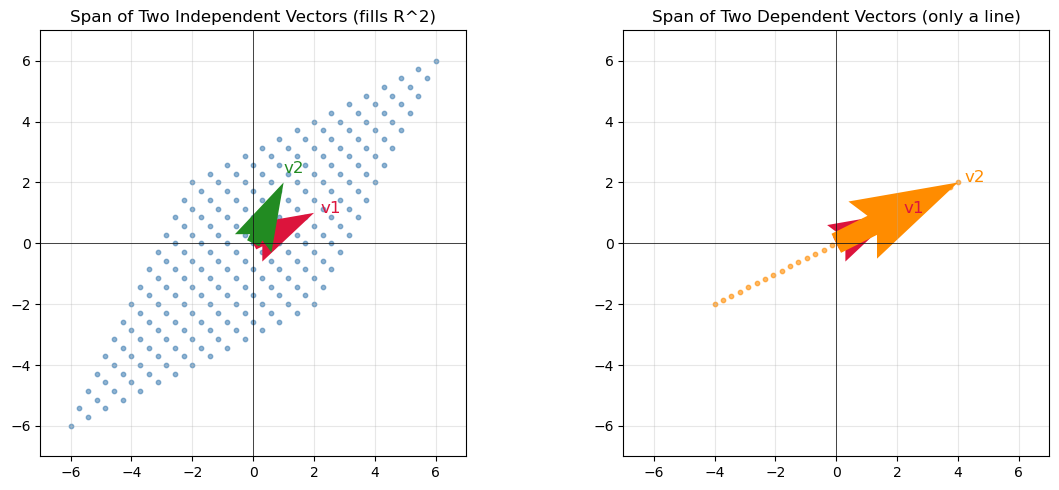

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Span of independent vectors ---
ax = axes[0]
v1 = np.array([2, 1])
v2 = np.array([1, 2])

a_vals = np.linspace(-2, 2, 15)
b_vals = np.linspace(-2, 2, 15)
points = np.array([a * v1 + b * v2 for a in a_vals for b in b_vals])

ax.scatter(points[:, 0], points[:, 1], c='steelblue', s=10, alpha=0.6, label='Span')
ax.quiver(0, 0, v1[0], v1[1], color='crimson', angles='xy', scale_units='xy', scale=1, width=0.05)
ax.quiver(0, 0, v2[0], v2[1], color='forestgreen', angles='xy', scale_units='xy', scale=1, width=0.05)

ax.set_xlim(-7, 7)
ax.set_ylim(-7, 7)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('Span of Two Independent Vectors (fills R^2)')
ax.text(v1[0]+0.2, v1[1], 'v1', color='crimson', fontsize=12)
ax.text(v2[0], v2[1]+0.3, 'v2', color='forestgreen', fontsize=12)

# --- Span of dependent vectors ---
ax = axes[1]
v1 = np.array([2, 1])
v2 = np.array([4, 2])

a_vals = np.linspace(-2, 2, 30)
points = np.array([a * v1 for a in a_vals])

ax.scatter(points[:, 0], points[:, 1], c='darkorange', s=10, alpha=0.6, label='Span')
ax.quiver(0, 0, v1[0], v1[1], color='crimson', angles='xy', scale_units='xy', scale=1, width=0.05)
ax.quiver(0, 0, v2[0], v2[1], color='darkorange', angles='xy', scale_units='xy', scale=1, width=0.05)

ax.set_xlim(-7, 7)
ax.set_ylim(-7, 7)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('Span of Two Dependent Vectors (only a line)')
ax.text(v1[0]+0.2, v1[1], 'v1', color='crimson', fontsize=12)
ax.text(v2[0]+0.2, v2[1], 'v2', color='darkorange', fontsize=12)

plt.tight_layout()
plt.show()


## 5. Gram-Schmidt Orthogonalization

Given a set of linearly independent vectors, the **Gram-Schmidt process** produces an **orthogonal basis** for the same subspace.

This is foundational for QR decomposition, PCA, and least-squares solvers in machine learning.

### Process
Given independent vectors $\{v_1, v_2\}$:
1. $u_1 = v_1$
2. $u_2 = v_2 - \text{proj}_{u_1}(v_2)$

Where $\text{proj}_{u}(v) = \frac{u \cdot v}{u \cdot u} u$.

The resulting $\{u_1, u_2\}$ are orthogonal and therefore linearly independent.


Original vectors:
v1 = [3. 1.]
v2 = [2. 2.]

Orthogonal basis:
u1 = [3. 1.]
u2 = [-0.4  1.2]
Dot product u1·u2 = -1.11e-15


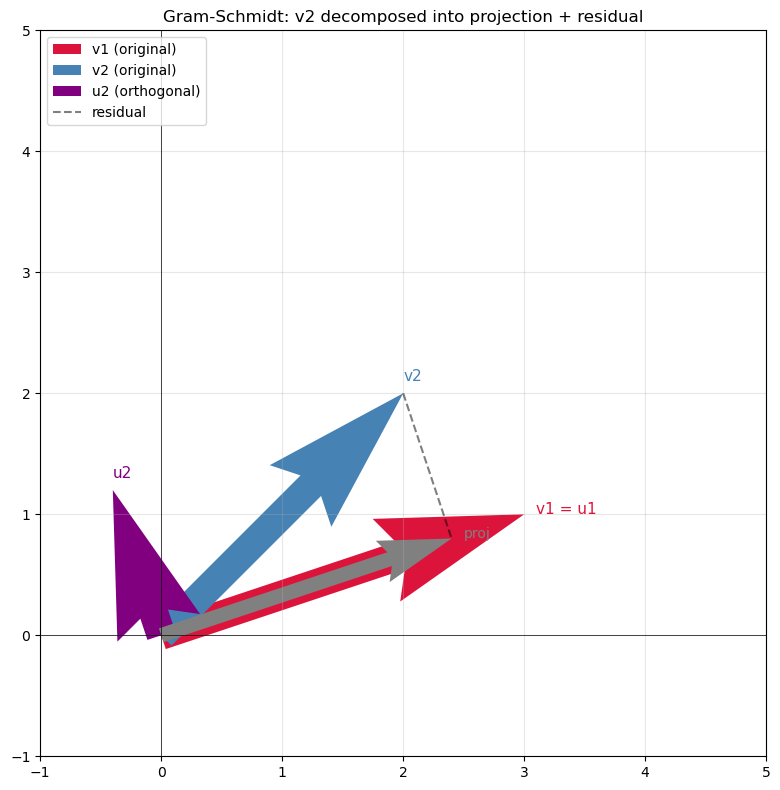

In [6]:
# Gram-Schmidt on two vectors
v1 = np.array([3.0, 1.0])
v2 = np.array([2.0, 2.0])

u1 = v1.copy()
proj = (np.dot(u1, v2) / np.dot(u1, u1)) * u1
u2 = v2 - proj

print("Original vectors:")
print(f"v1 = {v1}")
print(f"v2 = {v2}")
print()
print("Orthogonal basis:")
print(f"u1 = {u1}")
print(f"u2 = {u2}")
print(f"Dot product u1·u2 = {np.dot(u1, u2):.2e}")

fig, ax = plt.subplots(figsize=(8, 8))

# Draw original vectors
ax.quiver(0, 0, v1[0], v1[1], color='crimson', angles='xy', scale_units='xy', scale=1, width=0.04, label='v1 (original)')
ax.quiver(0, 0, v2[0], v2[1], color='steelblue', angles='xy', scale_units='xy', scale=1, width=0.04, label='v2 (original)')

# Draw orthogonal basis
ax.quiver(0, 0, u2[0], u2[1], color='purple', angles='xy', scale_units='xy', scale=1, width=0.04, label='u2 (orthogonal)')

# Draw projection of v2 onto v1
ax.quiver(0, 0, proj[0], proj[1], color='gray', angles='xy', scale_units='xy', scale=1, width=0.02)
ax.plot([v2[0], proj[0]], [v2[1], proj[1]], 'k--', alpha=0.5, label='residual')

# Labels
ax.text(v1[0]+0.1, v1[1], 'v1 = u1', color='crimson', fontsize=11)
ax.text(v2[0], v2[1]+0.1, 'v2', color='steelblue', fontsize=11)
ax.text(u2[0], u2[1]+0.1, 'u2', color='purple', fontsize=11)
ax.text(proj[0]+0.1, proj[1], 'proj', color='gray', fontsize=10)

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('Gram-Schmidt: v2 decomposed into projection + residual')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## 6. Summary

| Concept | Test / Criterion |
|---------|----------------|
| **Linear Independence** | Only trivial solution to $\sum c_i v_i = 0$ |
| **Determinant Test** | $\det(A) \neq 0$ for $n$ vectors in $\mathbb{R}^n$ |
| **Rank Test** | $\text{rank}(A) = \text{number of vectors}$ |
| **Geometric Check** | Do vectors span the full dimension? |
| **Gram-Schmidt** | Produces orthogonal basis from any independent set |

### Key Takeaways
- Independence means no vector is redundant — each adds a new dimension to the span.
- In $\mathbb{R}^n$, you can have at most $n$ linearly independent vectors.
- Linear dependence implies at least one vector can be expressed as a combination of the others.
- Orthogonal bases (via Gram-Schmidt) simplify projections, least-squares, and eigendecomposition in machine learning.
- 